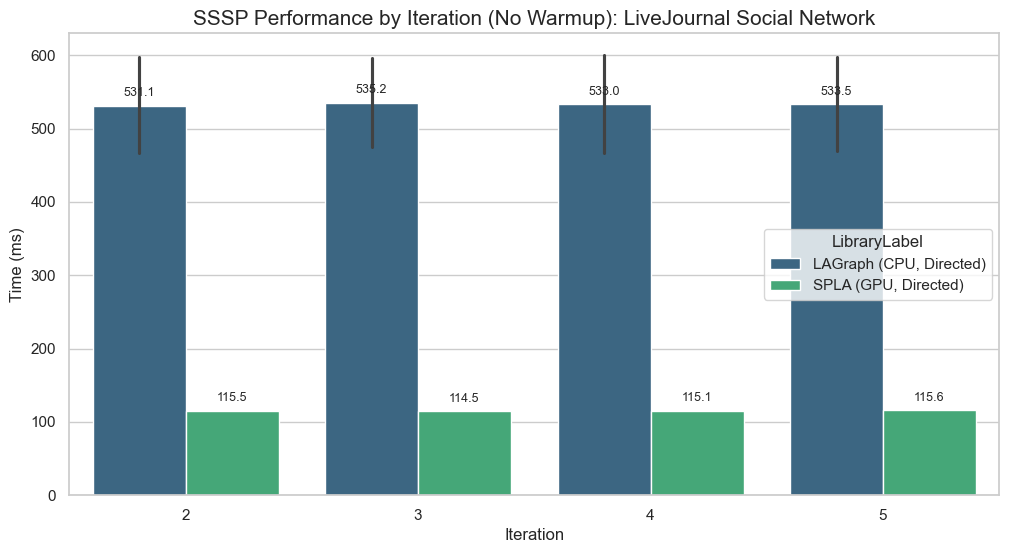

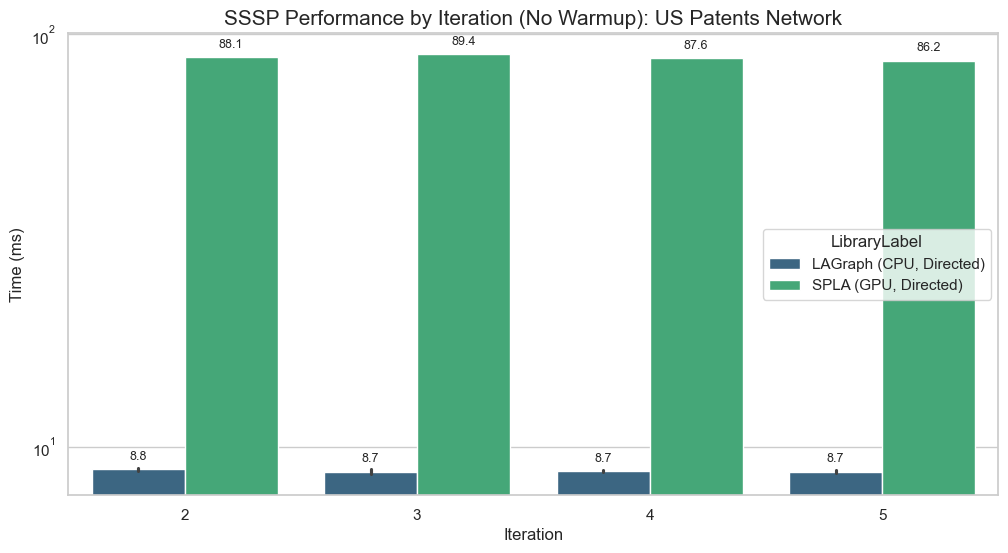

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sssp_raw = pd.read_csv('sssp/sssp_results.csv')

if 'Iteration' in sssp_raw.columns:
    df_filtered = sssp_raw[sssp_raw['Iteration'] > 1].copy()
elif 'Iters' in sssp_raw.columns:
    df_filtered = sssp_raw[sssp_raw['Iters'] > 1].copy()
else:
    df_filtered = sssp_raw.copy()

sns.set_theme(style="whitegrid")

def get_stats(group):
    data = group['Time_ms']
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    p_val = stats.shapiro(data)[1] if n >= 3 else np.nan
    if n > 1:
        ci = stats.t.interval(0.95, n-1, loc=mean, scale=std_err)
    else:
        ci = (mean, mean)
    return pd.Series({
        'Mean_ms': mean,
        'Median_ms': np.median(data),
        'CI_lower': ci[0],
        'CI_upper': ci[1],
        'Std_Err': std_err,
        'P_Normal': p_val
    })

sssp_stats = df_filtered.groupby(['Graph', 'Library', 'Version', 'Delta']).apply(get_stats).reset_index()

plot_df = df_filtered[df_filtered['Version'].isin(['Normal', 'GPU'])].copy()


def plot_iteration_comparison(df, graph_filename, title_label):
    data_subset = df[df['Graph'] == graph_filename].copy()
    if data_subset.empty: return

    label_map = {'LAGraph': 'LAGraph (CPU, Directed)', 'SPLA': 'SPLA (GPU, Directed)'}
    data_subset['LibraryLabel'] = data_subset['Library'].map(label_map)
    hue_order = ['LAGraph (CPU, Directed)', 'SPLA (GPU, Directed)']

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=data_subset, x='Iteration', y='Time_ms', hue='LibraryLabel', hue_order=hue_order, palette='viridis')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=9)

    plt.title(f'SSSP Performance by Iteration (No Warmup): {title_label}', fontsize=15)
    plt.ylabel('Time (ms)')
    if 'patents' in graph_filename.lower(): plt.yscale('log')
    plt.show()

plot_iteration_comparison(plot_df, 'soc-LiveJournal1.mtx', 'LiveJournal Social Network')
plot_iteration_comparison(plot_df, 'patents.mtx', 'US Patents Network')

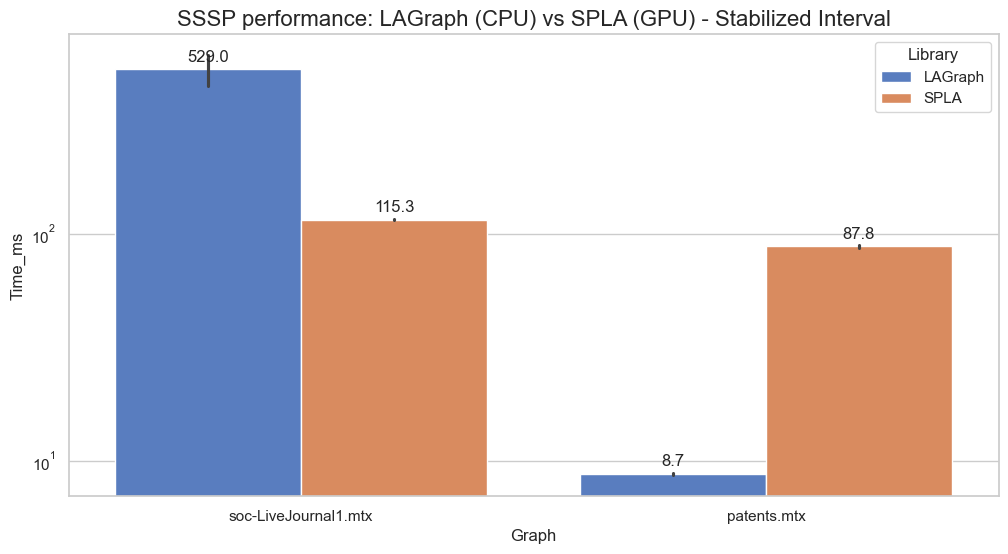

In [35]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x='Graph', y='Time_ms', hue='Library', palette='muted', estimator='median', errorbar='sd')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('SSSP performance: LAGraph (CPU) vs SPLA (GPU) - Stabilized Interval', fontsize=16)
plt.yscale('log')
plt.savefig("sssp/mean_time.png")
plt.show()

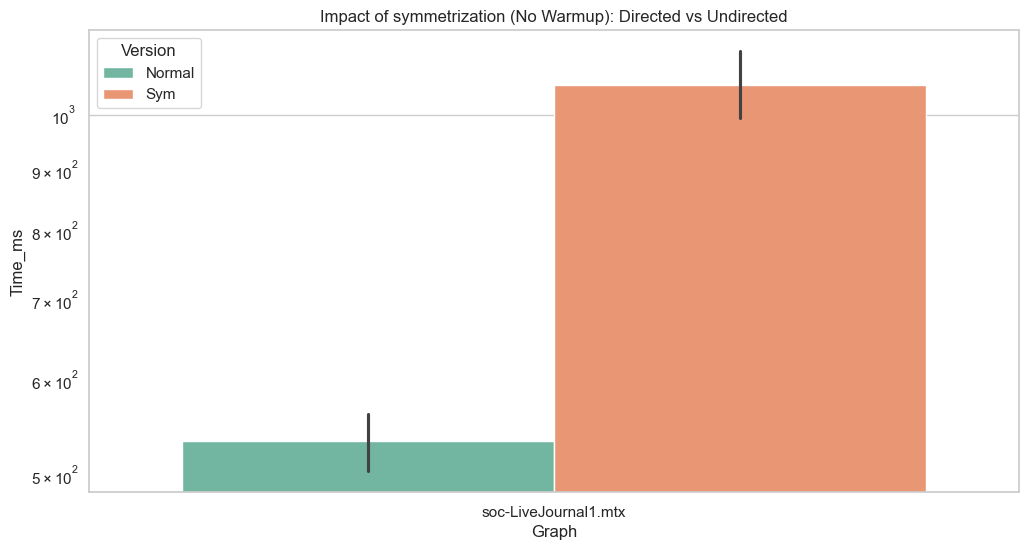

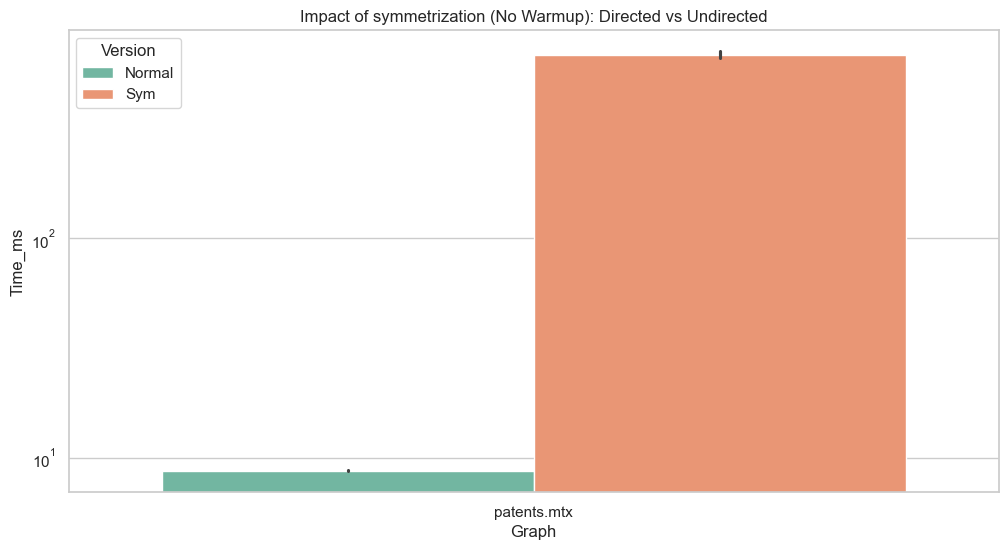

In [36]:
sym_cmp = df_filtered[(df_filtered['Library'] == 'LAGraph') & (df_filtered['Graph'] == 'soc-LiveJournal1.mtx')]
plt.figure(figsize=(12, 6))
sns.barplot(data=sym_cmp, x='Graph', y='Time_ms', hue='Version', palette='Set2')
plt.yscale('log')
plt.title('Impact of symmetrization (No Warmup): Directed vs Undirected')
plt.savefig("sssp/mean_sym_lj_time.png")
plt.show()

sym_cmp = df_filtered[(df_filtered['Library'] == 'LAGraph') & (df_filtered['Graph'] == 'patents.mtx')]
plt.figure(figsize=(12, 6))
sns.barplot(data=sym_cmp, x='Graph', y='Time_ms', hue='Version', palette='Set2')
plt.yscale('log')
plt.title('Impact of symmetrization (No Warmup): Directed vs Undirected')
plt.savefig("sssp/mean_sym_patents_time.png")
plt.show()



/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_10873/2510866697.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='magma')


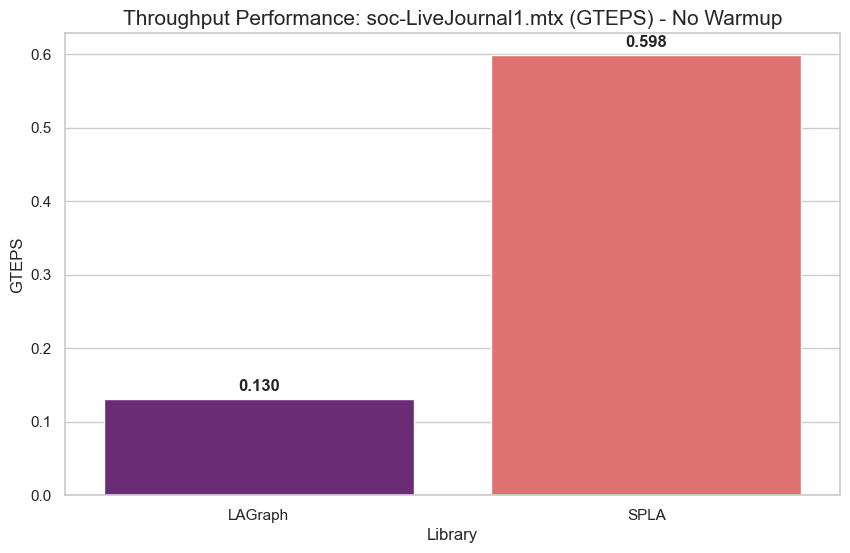

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_10873/2510866697.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='magma')


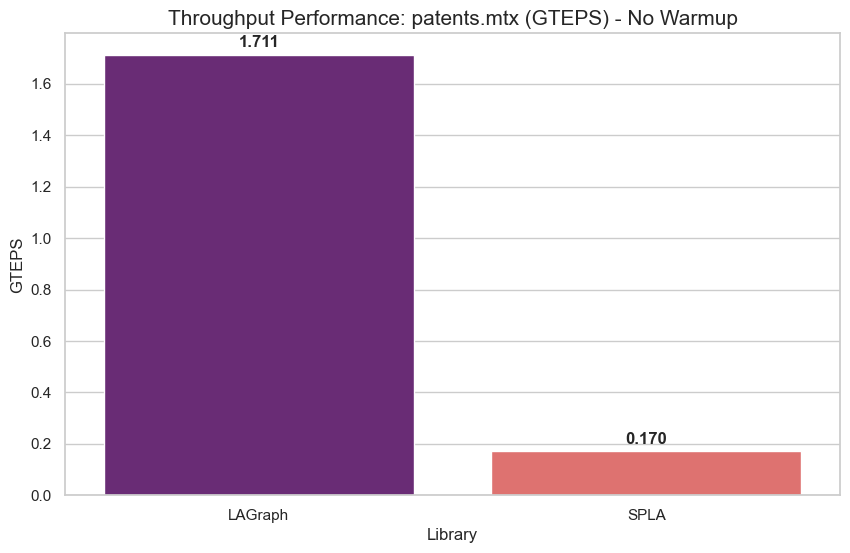

In [37]:
def plot_gteps(df_source, target_graph, edges_dict):
    gteps_df = df_source[df_source['Graph'] == target_graph].copy()
    gteps_df = gteps_df.groupby(['Graph', 'Library'])['Time_ms'].median().reset_index()
    gteps_df['GTEPS'] = gteps_df.apply(lambda x: edges_dict[x['Graph']] / (x['Time_ms'] * 1e6), axis=1)
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='magma')
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')
    plt.title(f'Throughput Performance: {target_graph} (GTEPS) - No Warmup', fontsize=15)
    plt.savefig(f"sssp/throughput{target_graph}.png")
    plt.show()

plot_gteps(plot_df, 'soc-LiveJournal1.mtx', edges)
plot_gteps(plot_df, 'patents.mtx', edges)